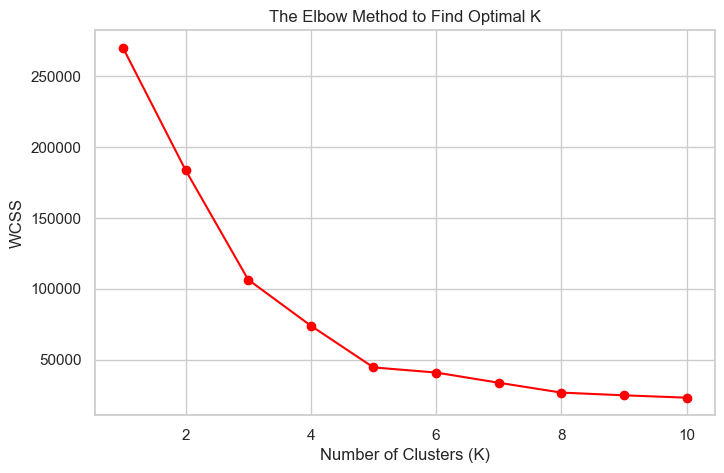

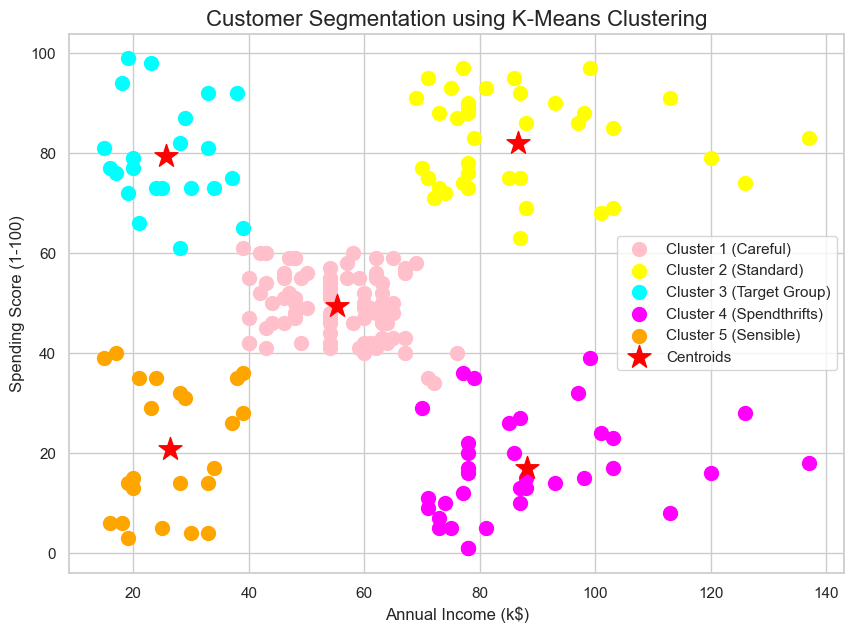

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Set style for the plots
sns.set_theme(style="whitegrid")

# 1. Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# 2. Select features for clustering (Annual Income and Spending Score)
X = df.iloc[:, [3, 4]].values

# 3. Use the Elbow Method to find the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', color='red')
plt.title('The Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

# 4. Train the K-Means model with the optimal number of clusters (K = 5)
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster labels to the original dataframe
df['Cluster'] = y_kmeans

# 5. Visualize the final Customer Clusters
plt.figure(figsize=(10, 7))

# Plotting the 5 different clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='pink', label='Cluster 1 (Careful)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='yellow', label='Cluster 2 (Standard)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='cyan', label='Cluster 3 (Target Group)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='magenta', label='Cluster 4 (Spendthrifts)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='orange', label='Cluster 5 (Sensible)')

# Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', label='Centroids', marker='*')

plt.title('Customer Segmentation using K-Means Clustering', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()

# Save the final cluster plot as an image file
plt.savefig('customer_clusters.png')
plt.show()